In [1]:
# Kurulum ve veri dosyasının konumu
import importlib.metadata
import subprocess
import sys

try:
    statsmodels_version = importlib.metadata.version("statsmodels")
except importlib.metadata.PackageNotFoundError:
    statsmodels_version = None
if statsmodels_version != "0.15.0":
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels==0.15.0"])


In [2]:
# Veriyi okuma ve kontrol etme
from pathlib import Path
import copy
import hashlib
import importlib.metadata
import json
import platform
import random
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

ROOT = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
DATA_FILE = ROOT / 'data/META_yahoo.csv'
if not DATA_FILE.exists():
    DATA_FILE = ROOT / 'META_yahoo.csv'
if not DATA_FILE.exists():
    raise FileNotFoundError('Upload META_yahoo.csv in Colab, or run inside the project folder.')
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)
(ROOT / 'models').mkdir(exist_ok=True)
CONFIG = dict(seed=42, lookback=20, train_fraction=0.64, validation_fraction=0.16,
              input_size=1, hidden_size=32, num_layers=2, batch_size=64,
              max_epochs=100, patience=12, learning_rate=0.001, device='cpu')
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
versions = {p: importlib.metadata.version(p) for p in ['torch','numpy','pandas','scikit-learn','matplotlib']}
print('Python:', platform.python_version(), '| packages:', versions, '| device: CPU')
print('Config:', CONFIG)



Python: 3.12.14 | packages: {'torch': '2.14.0+cpu', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scikit-learn': '1.8.0', 'matplotlib': '3.10.8'} | device: CPU
Config: {'seed': 42, 'lookback': 20, 'train_fraction': 0.64, 'validation_fraction': 0.16, 'input_size': 1, 'hidden_size': 32, 'num_layers': 2, 'batch_size': 64, 'max_epochs': 100, 'patience': 12, 'learning_rate': 0.001, 'device': 'cpu'}


In [3]:
# Zaman sıralı ayrım ve 20 günlük fiyat pencereleri
raw = pd.read_csv(DATA_FILE)
audit = {'rows': len(raw), 'columns': list(raw.columns),
         'original_dtypes': raw.dtypes.astype(str).to_dict(),
         'missing': raw.isna().sum().to_dict(), 'duplicate_dates': int(raw.Date.duplicated().sum())}
df = raw.copy()
df['Date'] = pd.to_datetime(df.Date, errors='raise')
df = df.sort_values('Date').reset_index(drop=True)
assert {'Date','Open','High','Low','Close','Volume'}.issubset(df.columns)
assert not df.isna().any().any(), 'Missing values require review'
assert not df.Date.duplicated().any(), 'Duplicate dates require review'
assert np.isfinite(df.select_dtypes(include='number')).all().all()
assert df.Close.gt(0).all()
ohlc_bad = (df.High < df[['Open','Close','Low']].max(axis=1)) | (df.Low > df[['Open','Close','High']].min(axis=1))
audit['ohlc_inconsistent_rows'] = df.loc[ohlc_bad].to_dict('records')
audit['ohlc_action'] = 'Flagged without inventing corrections; only Close used by the models.'
assert df.Close.between(df.Low, df.High).all(), 'Close outside daily range requires review'
assert df.Volume.ge(0).all()
returns = df.Close.pct_change()
audit.update(start=str(df.Date.min().date()), end=str(df.Date.max().date()),
             sorted_original=bool(pd.to_datetime(raw.Date).is_monotonic_increasing),
             gap_days=df.Date.diff().dt.days.value_counts().sort_index().to_dict(),
             weekend_rows=int(df.Date.dt.dayofweek.ge(5).sum()),
             close_summary=df.Close.describe().to_dict(),
             large_moves=df.loc[returns.abs().gt(0.20),['Date','Close']].assign(return_pct=returns*100).to_dict('records'),
             frequency='Observed trading days; exchange calendar completeness not independently verified')
print(json.dumps(audit, indent=2, default=str))
(RESULTS/'data_audit.json').write_text(json.dumps(audit, indent=2, default=str))



{
  "rows": 2948,
  "columns": [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
  ],
  "original_dtypes": {
    "Date": "object",
    "Open": "float64",
    "High": "float64",
    "Low": "float64",
    "Close": "float64",
    "Adj Close": "float64",
    "Volume": "int64"
  },
  "missing": {
    "Date": 0,
    "Open": 0,
    "High": 0,
    "Low": 0,
    "Close": 0,
    "Adj Close": 0,
    "Volume": 0
  },
  "duplicate_dates": 0,
  "ohlc_inconsistent_rows": [],
  "ohlc_action": "Flagged without inventing corrections; only Close used by the models.",
  "start": "2015-01-02",
  "end": "2026-09-23",
  "sorted_original": true,
  "gap_days": {
    "1.0": 2307,
    "2.0": 28,
    "3.0": 529,
    "4.0": 83
  },
  "weekend_rows": 0,
  "close_summary": {
    "count": 2948.0,
    "mean": 284.8747692781023,
    "std": 189.95324061768505,
    "min": 74.0500030518,
    "25%": 148.20500564577497,
    "50%": 198.4749984741,
    "75%": 351.4024963379,
    "max"

train X: (1866, 20, 1) y: (1866, 1)
validation X: (472, 20, 1) y: (472, 1)
test X: (590, 20, 1) y: (590, 1)
     split target_start target_end  samples
     train   2015-02-02 2022-06-29     1866
validation   2022-06-30 2024-05-15      472
      test   2024-05-16 2026-09-23      590
Scaler fitted through: 2022-06-29
Leakage assertions passed. Test values outside [-1,1] are retained without clipping.


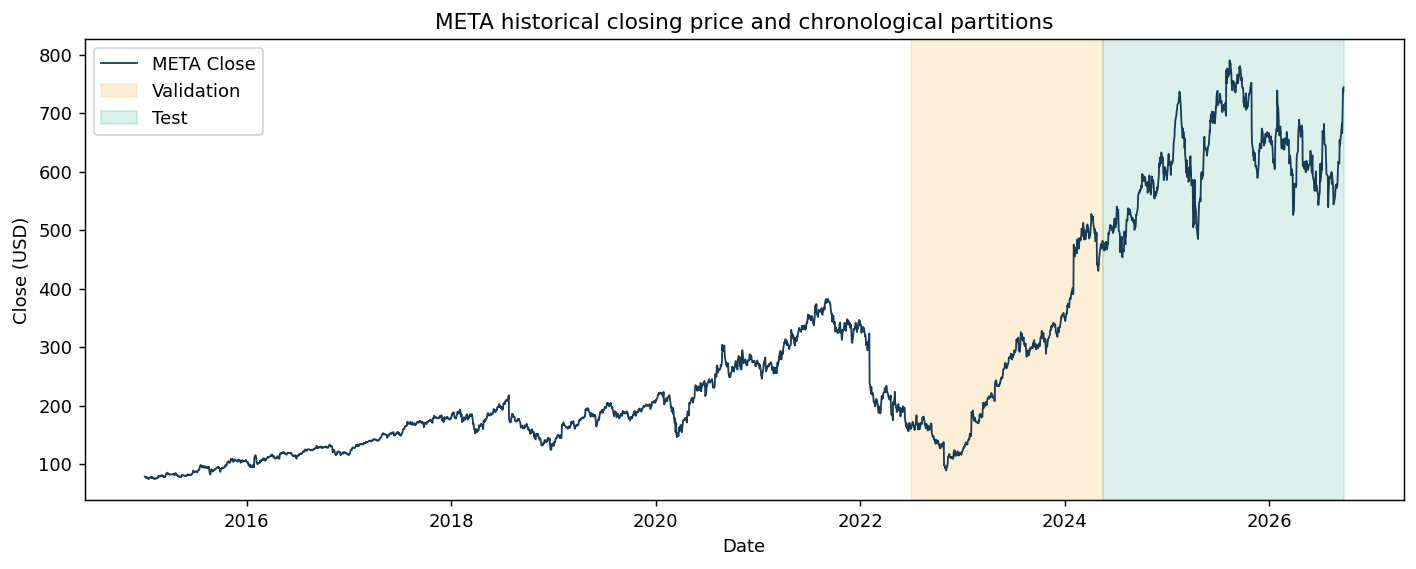

In [4]:
# LSTM ve GRU modellerinin eğitimi
n = len(df)
train_end = int(n * CONFIG['train_fraction'])
val_end = int(n * (CONFIG['train_fraction'] + CONFIG['validation_fraction']))
prices = df[['Close']].to_numpy(dtype=np.float64)
scaler = MinMaxScaler(feature_range=(-1,1))
scaler.fit(prices[:train_end])
scaled = scaler.transform(prices).astype(np.float32)
L = CONFIG['lookback']
target_index = np.arange(L, n)
input_index = target_index[:,None] - np.arange(L,0,-1)[None,:]
X = scaled[input_index]
y = scaled[target_index]
masks = {'train':target_index < train_end,
         'validation':(target_index >= train_end) & (target_index < val_end),
         'test':target_index >= val_end}
assert np.all(input_index.max(axis=1) == target_index-1)
assert np.all(input_index < target_index[:,None])
assert scaler.n_samples_seen_ == train_end
assert np.allclose(scaler.data_max_, prices[:train_end].max(axis=0))
assert masks['train'].astype(int).sum()+masks['validation'].sum()+masks['test'].sum() == len(y)
assert target_index[masks['train']].max() < target_index[masks['validation']].min()
assert target_index[masks['validation']].max() < target_index[masks['test']].min()
sets = {k:(torch.from_numpy(X[m]),torch.from_numpy(y[m])) for k,m in masks.items()}
splits=[]
for name, mask in masks.items():
    dates=df.Date.iloc[target_index[mask]]
    splits.append({'split':name, 'target_start':str(dates.min().date()),
                   'target_end':str(dates.max().date()), 'samples':int(mask.sum())})
    print(name, 'X:',tuple(sets[name][0].shape), 'y:',tuple(sets[name][1].shape))
split_table=pd.DataFrame(splits)
print(split_table.to_string(index=False))
split_table.to_csv(RESULTS/'splits.csv',index=False)
print('Scaler fitted through:',df.Date.iloc[train_end-1].date())
print('Leakage assertions passed. Test values outside [-1,1] are retained without clipping.')
fig,ax=plt.subplots(figsize=(11,4.5))
ax.plot(df.Date,df.Close,lw=1,color='#183b56',label='META Close')
ax.axvspan(df.Date.iloc[train_end],df.Date.iloc[val_end-1],color='#f1b94b',alpha=.22,label='Validation')
ax.axvspan(df.Date.iloc[val_end],df.Date.iloc[-1],color='#5cb8a8',alpha=.22,label='Test')
ax.set(title='META historical closing price and chronological partitions',xlabel='Date',ylabel='Close (USD)')
ax.legend();fig.tight_layout();fig.savefig(RESULTS/'price_and_splits.png',dpi=160);plt.show();plt.close(fig)

(RESULTS/'experiment_plan.json').write_text(json.dumps({'config':CONFIG,'data_sha256':hashlib.sha256(DATA_FILE.read_bytes()).hexdigest(),'selection':'lowest validation MSE checkpoint; no test tuning','variants':['LSTM','GRU'],'target':'next observed trading day Close'},indent=2))



In [5]:
# Fiyat tahminleri ve son fiyat kıyası
class RecurrentRegressor(nn.Module):
    def __init__(self, kind):
        super().__init__()
        recurrent = nn.LSTM if kind.endswith('LSTM') else nn.GRU
        self.rnn = recurrent(input_size=CONFIG['input_size'], hidden_size=CONFIG['hidden_size'],
                             num_layers=CONFIG['num_layers'], batch_first=True)
        self.head = nn.Linear(CONFIG['hidden_size'],1)
    def forward(self, x):
        # Her bağımsız pencere için gizli durum başlangıçta sıfırdır.
        out, _ = self.rnn(x)
        return self.head(out[:,-1,:])

@torch.no_grad()
def predict_scaled(model, x):
    model.eval()
    return torch.cat([model(b) for b in x.split(256)]).numpy()

def fit_model(kind, datasets):
    torch.manual_seed(CONFIG['seed'])
    model=RecurrentRegressor(kind)
    generator=torch.Generator().manual_seed(CONFIG['seed'])
    # Yalnızca eğitim örneklerinin sırası karıştırılır; pencere içindeki günlerin sırası korunur.
    loader=DataLoader(TensorDataset(*datasets['train']),batch_size=CONFIG['batch_size'],
                      shuffle=True,generator=generator,num_workers=0)
    optimizer=torch.optim.Adam(model.parameters(),lr=CONFIG['learning_rate'])
    criterion=nn.MSELoss()
    best_loss=float('inf');best_state=None;best_epoch=0;stale=0;history=[]
    start=time.perf_counter()
    for epoch in range(1,CONFIG['max_epochs']+1):
        model.train(); total=0
        for xb,yb in loader:
            optimizer.zero_grad()
            prediction=model(xb)             # Tahmin
            loss=criterion(prediction,yb)    # Kayıp hesabı
            assert torch.isfinite(loss)
            loss.backward()                  # Parametrelere göre türevler
            optimizer.step()                 # Parametre güncellemesi
            total+=loss.item()*len(xb)
        val_prediction=predict_scaled(model,datasets['validation'][0])
        val_loss=float(np.mean((val_prediction-datasets['validation'][1].numpy())**2))
        history.append({'epoch':epoch,'train_mse_scaled':total/len(datasets['train'][0]),
                        'validation_mse_scaled':val_loss})
        if val_loss < best_loss:
            best_loss=val_loss;best_state=copy.deepcopy(model.state_dict());best_epoch=epoch;stale=0
        else:
            stale+=1
        if epoch==1 or epoch%10==0:
            print(f'{kind} epoch {epoch}: train={history[-1]["train_mse_scaled"]:.6f}, validation={val_loss:.6f}',flush=True)
        if stale >= CONFIG['patience']:
            break
    elapsed=time.perf_counter()-start
    model.load_state_dict(best_state)
    h=pd.DataFrame(history);h.to_csv(RESULTS/f'{kind.lower()}_history.csv',index=False)
    torch.save(model.state_dict(), ROOT/'models'/f'{kind.lower()}.pt')
    meta={'model':kind,'epochs_run':len(history),'best_epoch':best_epoch,'training_seconds':elapsed,
          'parameters':sum(p.numel() for p in model.parameters())}
    print('Training complete:',meta,flush=True)
    return model,h,meta

trained={};histories={};training_meta=[]
for kind in ['LSTM','GRU']:
    trained[kind],histories[kind],meta=fit_model(kind, sets)
    training_meta.append(meta)
# Doğrulama sonucuna göre seçilen ağırlıklar test tahminlerinden önce sabitlenir.
pd.DataFrame(training_meta).to_csv(RESULTS/'training_summary.csv',index=False)



LSTM epoch 1: train=0.217547, validation=0.577835
LSTM epoch 10: train=0.003001, validation=0.023996
LSTM epoch 20: train=0.002255, validation=0.011540
LSTM epoch 30: train=0.001955, validation=0.009539
LSTM epoch 40: train=0.001639, validation=0.009830
LSTM epoch 50: train=0.001431, validation=0.007633
LSTM epoch 60: train=0.001241, validation=0.007110
LSTM epoch 70: train=0.001199, validation=0.004381
LSTM epoch 80: train=0.001425, validation=0.005086
Training complete: {'model': 'LSTM', 'epochs_run': 82, 'best_epoch': 70, 'training_seconds': 9.668427199999314, 'parameters': 12961}
GRU epoch 1: train=0.127092, validation=0.080435
GRU epoch 10: train=0.001703, validation=0.017122
GRU epoch 20: train=0.001263, validation=0.010582
GRU epoch 30: train=0.001115, validation=0.006991
GRU epoch 40: train=0.001021, validation=0.007451
GRU epoch 50: train=0.000993, validation=0.005992
GRU epoch 60: train=0.000976, validation=0.005900
GRU epoch 70: train=0.000978, validation=0.003912
GRU epoch 

Price-level model metrics:
     split model    n       MSE    RMSE     MAE
     train Naive 1866   22.2709  4.7192  2.7820
     train  LSTM 1866   30.9157  5.5602  3.4134
     train   GRU 1866   24.7047  4.9704  2.9668
validation Naive  472   57.0048  7.5502  4.6527
validation  LSTM  472  103.9923 10.1977  6.6865
validation   GRU  472   86.5358  9.3025  5.9009
      test Naive  590  212.9290 14.5921  9.9607
      test  LSTM  590 7481.5401 86.4959 74.6013
      test   GRU  590 5377.8907 73.3341 63.8010


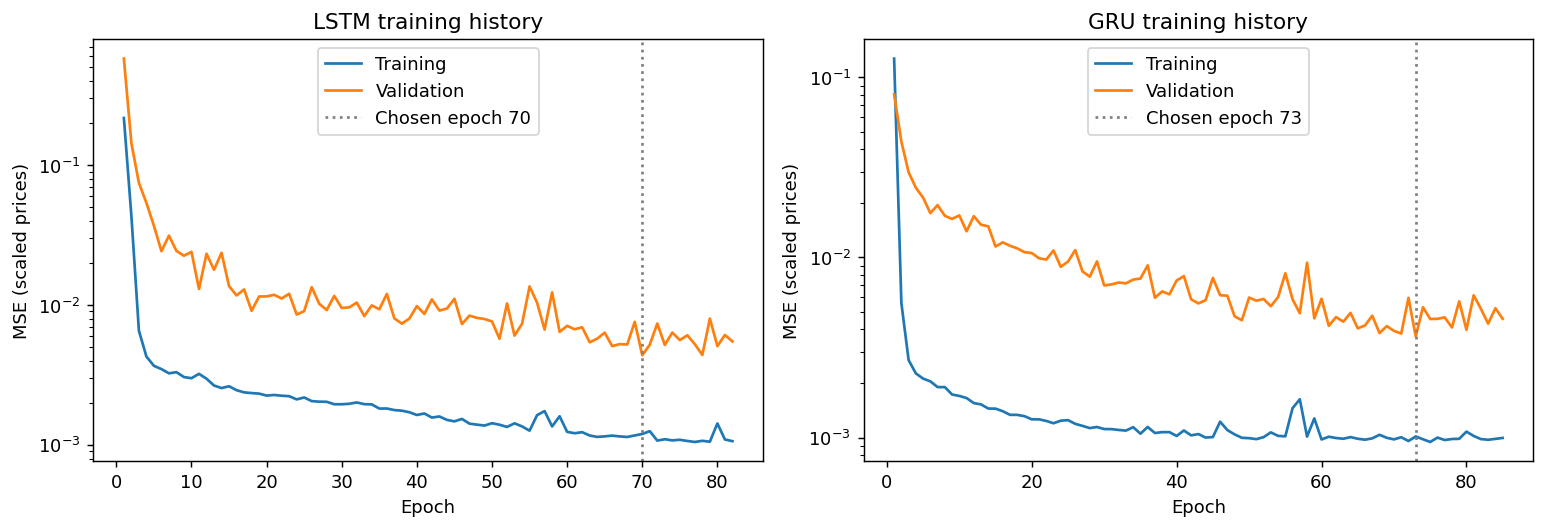

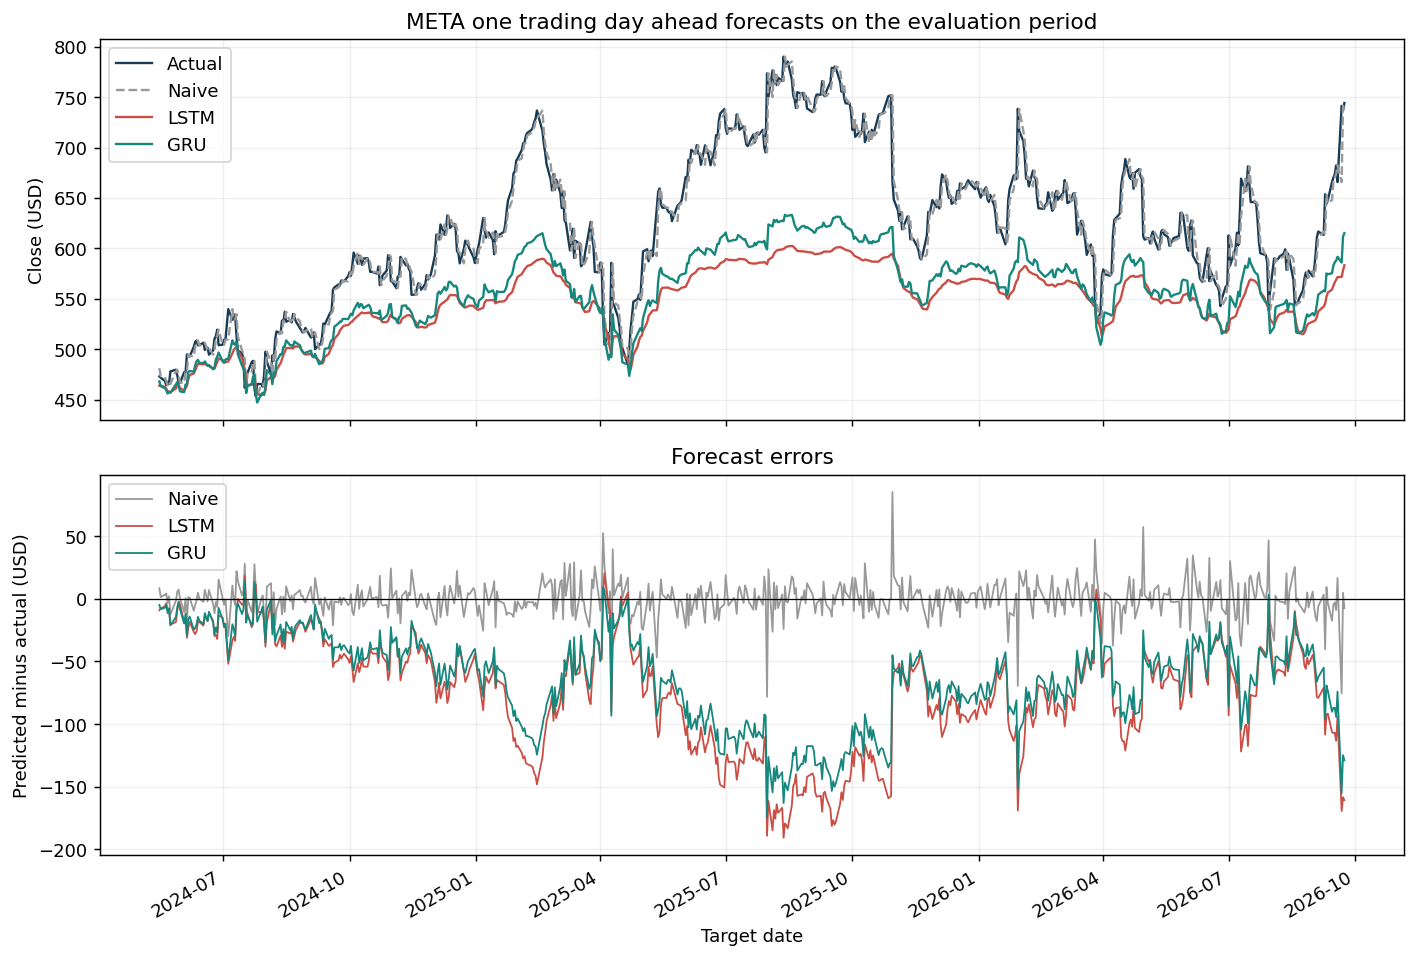

In [6]:
# Log getiri modelleri ve AR(20) kıyası
rows=[];test_predictions=None
for split,mask in masks.items():
    idx=target_index[mask]
    actual=prices[idx,0]
    predictions={'Naive':prices[idx-1,0]}
    for name,model in trained.items():
        predictions[name]=scaler.inverse_transform(predict_scaled(model,sets[split][0])).astype(np.float64)[:,0]
    for name,pred in predictions.items():
        error=pred-actual
        rows.append({'split':split,'model':name,'n':len(actual),'MSE':float(np.mean(error**2)),
                     'RMSE':float(np.sqrt(np.mean(error**2))),'MAE':float(np.mean(np.abs(error)))})
    if split=='test':
        test_predictions=pd.DataFrame({'Date':df.Date.iloc[idx].to_numpy(),'Actual':actual,**predictions})
metrics=pd.DataFrame(rows)
metrics.to_csv(RESULTS/'metrics.csv',index=False)
test_predictions.to_csv(RESULTS/'test_predictions.csv',index=False)
print('Price-level model metrics:')
print(metrics.round(4).to_string(index=False))
fig,axes=plt.subplots(1,2,figsize=(12,4.2))
for ax,kind in zip(axes,['LSTM','GRU']):
    h=histories[kind]
    ax.plot(h.epoch,h.train_mse_scaled,label='Training')
    ax.plot(h.epoch,h.validation_mse_scaled,label='Validation')
    best=next(m['best_epoch'] for m in training_meta if m['model']==kind)
    ax.axvline(best,color='gray',ls=':',label=f'Chosen epoch {best}')
    ax.set(title=f'{kind} training history',xlabel='Epoch',ylabel='MSE (scaled prices)',yscale='log');ax.legend()
fig.tight_layout();fig.savefig(RESULTS/'training_history.png',dpi=160);plt.show();plt.close(fig)
fig,axes=plt.subplots(2,1,figsize=(11,7.5),sharex=True)
colors={'Actual':'#183b56','Naive':'#999999','LSTM':'#cb4e45','GRU':'#16877c'}
for col in ['Actual','Naive','LSTM','GRU']:
    axes[0].plot(test_predictions.Date,test_predictions[col],label=col,color=colors[col],lw=1.3,ls='--' if col=='Naive' else '-')
for col in ['Naive','LSTM','GRU']:
    axes[1].plot(test_predictions.Date,test_predictions[col]-test_predictions.Actual,label=col,color=colors[col],lw=1)
axes[0].set(title='META one trading day ahead forecasts on the evaluation period',ylabel='Close (USD)')
axes[1].set(title='Forecast errors',xlabel='Target date',ylabel='Predicted minus actual (USD)')
axes[1].axhline(0,color='black',lw=.7)
for ax in axes:ax.legend(loc='upper left');ax.grid(alpha=.2)
fig.autofmt_xdate();fig.tight_layout();fig.savefig(RESULTS/'test_predictions.png',dpi=160);plt.show();plt.close(fig)
provenance={'source':'https://finance.yahoo.com/quote/META/history/',
            'member':'META_yahoo.csv','retrieved_on':'2026-09-24',
            'sha256':hashlib.sha256((DATA_FILE).read_bytes()).hexdigest(),
            'python':platform.python_version(),'versions':versions,'config':CONFIG,
            'scaler':{'min':scaler.data_min_.tolist(),'max':scaler.data_max_.tolist(),
                      'scale':scaler.scale_.tolist(),'offset':scaler.min_.tolist(),'train_rows':train_end},
            'test_protocol':'Fixed weights, rolling one-step prediction with actually observed past closes; no test tuning.'}
(RESULTS/'run_metadata.json').write_text(json.dumps(provenance,indent=2))




In [7]:
# Hata ölçüleri ve istatistiksel kontroller
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

# Getiri modeli ilk fiyat denemesinin sonuçları görüldükten sonra eklendi.
# Aynı değerlendirme günleri kullanılıyor; bu ek deney bağımsız bir doğrulama değildir.
log_returns = np.diff(np.log(prices[:, 0]))
return_scaler = StandardScaler().fit(log_returns[:train_end-1, None])
return_scaled = return_scaler.transform(log_returns[:, None]).astype(np.float32)
return_target_index = np.arange(L+1, n)
# log_returns dizisindeki t-1. satır, t gününün getirisidir; girdiler hedef günden önce biter.
return_input_index = return_target_index[:, None] - np.arange(L+1, 1, -1)[None, :]
RX = return_scaled[return_input_index]
Ry = return_scaled[return_target_index-1]
return_masks = {'train':return_target_index < train_end,
                'validation':(return_target_index >= train_end) & (return_target_index < val_end),
                'test':return_target_index >= val_end}
return_sets = {k:(torch.from_numpy(RX[m]), torch.from_numpy(Ry[m])) for k,m in return_masks.items()}
assert return_scaler.n_samples_seen_ == train_end-1
assert np.all(return_input_index.max(axis=1) == return_target_index-2)
for split in ['validation','test']:
    assert np.array_equal(return_target_index[return_masks[split]],target_index[masks[split]])
print('Return pipeline:', {k:tuple(v[0].shape) for k,v in return_sets.items()})
return_plan = {'feature':'20 lagged log Close returns','target':'next log Close return',
               'price_reconstruction':'P_t * exp(predicted_log_return)',
               'return_scaler_fit_rows':train_end-1,'config':CONFIG,
               'evaluation_status':'Exploratory extension after initial price test review; no return-model tuning on test'}
(RESULTS/'return_experiment_plan.json').write_text(json.dumps(return_plan,indent=2))
return_models={}
for kind in ['LSTM','GRU']:
    name='Return_'+kind
    return_models[name],histories[name],meta=fit_model(name,return_sets)
    training_meta.append(meta)
# Aynı 20 geçmiş getiriyle basit bir doğrusal regresyon kıyası.
ar_model=LinearRegression().fit(RX[return_masks['train'],:,0],Ry[return_masks['train'],0])
return_predictions={}
for split,mask in return_masks.items():
    idx=return_target_index[mask]
    actual=prices[idx,0]
    previous=prices[idx-1,0]
    for name in ['Return_LSTM','Return_GRU','AR20_Return']:
        if name=='AR20_Return':
            scaled_prediction=ar_model.predict(RX[mask,:,0]).reshape(-1,1)
        else:
            scaled_prediction=predict_scaled(return_models[name],return_sets[split][0])
        predicted_return=return_scaler.inverse_transform(scaled_prediction.astype(np.float64))[:,0]
        prediction=previous*np.exp(predicted_return)
        assert np.isfinite(prediction).all()
        error=prediction-actual
        rows.append({'split':split,'model':name,'n':len(actual),'MSE':float(np.mean(error**2)),
                     'RMSE':float(np.sqrt(np.mean(error**2))),'MAE':float(np.mean(np.abs(error)))})
        if split=='test':
            test_predictions[name]=prediction
            return_predictions[name]=predicted_return
pd.DataFrame(rows).to_csv(RESULTS/'metrics_all_splits.csv',index=False)
pd.DataFrame(training_meta).to_csv(RESULTS/'training_summary.csv',index=False)
test_predictions.to_csv(RESULTS/'test_predictions.csv',index=False)
# Ölçekleyici ve regresyon katsayıları tahminleri yeniden üretmek için saklanır.
provenance['return_scaler']={'mean':return_scaler.mean_.tolist(),'scale':return_scaler.scale_.tolist()}
provenance['ar20']={'coefficients':ar_model.coef_.tolist(),'intercept':float(ar_model.intercept_)}
provenance['versions'].update({p:importlib.metadata.version(p) for p in ['scipy','statsmodels']})
provenance['evaluation_status']=return_plan['evaluation_status']
(RESULTS/'run_metadata.json').write_text(json.dumps(provenance,indent=2))



Return pipeline: {'train': (1865, 20, 1), 'validation': (472, 20, 1), 'test': (590, 20, 1)}
Return_LSTM epoch 1: train=1.008132, validation=1.823881
Return_LSTM epoch 10: train=0.999896, validation=1.823466
Return_LSTM epoch 20: train=0.997995, validation=1.823395
Return_LSTM epoch 30: train=0.978131, validation=1.828624
Training complete: {'model': 'Return_LSTM', 'epochs_run': 37, 'best_epoch': 25, 'training_seconds': 3.8927157469997837, 'parameters': 12961}
Return_GRU epoch 1: train=1.011267, validation=1.817361
Return_GRU epoch 10: train=0.998962, validation=1.820847
Return_GRU epoch 20: train=0.994845, validation=1.817406
Return_GRU epoch 30: train=0.975764, validation=1.816135
Training complete: {'model': 'Return_GRU', 'epochs_run': 37, 'best_epoch': 25, 'training_seconds': 8.93849549100014, 'parameters': 9729}


In [8]:
# Tahmin ve eğitim grafikleri
actual=test_predictions.Actual.to_numpy()
previous=test_predictions.Naive.to_numpy()
actual_return=np.log(actual/previous)
naive_sse=np.sum((actual-previous)**2)
summary=[];return_summary=[];residual_rows=[]
model_names=['Naive','LSTM','GRU','AR20_Return','Return_LSTM','Return_GRU']
for name in model_names:
    prediction=test_predictions[name].to_numpy()
    error=prediction-actual
    mse=np.mean(error**2)
    summary.append({'model':name,'n':len(actual),'MSE':mse,'RMSE':np.sqrt(mse),
                    'MAE':np.mean(np.abs(error)),'R2':r2_score(actual,prediction),
                    'R2_OS_vs_naive':1-np.sum(error**2)/naive_sse,
                    'mean_error':np.mean(error)})
    implied_return=np.log(prediction/previous)
    return_summary.append({'model':name,'return_RMSE':np.sqrt(np.mean((implied_return-actual_return)**2)),
                           'return_R2':r2_score(actual_return,implied_return),
                           'return_R2_OS_vs_zero':1-np.sum((implied_return-actual_return)**2)/np.sum(actual_return**2)})
    lb=acorr_ljungbox(error,lags=[10],model_df=0,return_df=True)
    residual_rows.append({'model':name,'lag':10,'statistic':lb.lb_stat.iloc[0],
                          'p_value':lb.lb_pvalue.iloc[0],'mean_error':np.mean(error)})
summary=pd.DataFrame(summary);return_summary=pd.DataFrame(return_summary)
summary.to_csv(RESULTS/'comparison.csv',index=False)
return_summary.to_csv(RESULTS/'return_comparison.csv',index=False)
pd.DataFrame(residual_rows).to_csv(RESULTS/'ljung_box.csv',index=False)
adf_rows=[]
for label,series,reg in [('log_price',np.log(prices[:train_end,0]),'c'),
                         ('log_price_with_trend',np.log(prices[:train_end,0]),'ct'),
                         ('log_return',log_returns[:train_end-1],'c')]:
    result=adfuller(series,regression=reg,autolag='AIC',result_object=False)
    adf_rows.append({'series':label,'deterministic_terms':reg,'statistic':result[0],
                     'p_value':result[1],'selected_lags':result[2],'nobs':result[3],
                     'critical_5pct':result[4]['5%']})
pd.DataFrame(adf_rows).to_csv(RESULTS/'adf_training.csv',index=False)
print('Price-scale comparison:');print(summary.round(4).to_string(index=False))
print('Return-scale comparison:');print(return_summary.round(5).to_string(index=False))
print('Training-sample ADF:');print(pd.DataFrame(adf_rows).to_string(index=False))
print('Ljung-Box (lag 10; exploratory, homoskedastic reference p-values):')
print(pd.DataFrame(residual_rows).to_string(index=False))



Price-scale comparison:
      model   n       MSE    RMSE     MAE      R2  R2_OS_vs_naive  mean_error
      Naive 590  212.9290 14.5921  9.9607  0.9642          0.0000     -0.4450
       LSTM 590 7481.5401 86.4959 74.6013 -0.2578        -34.1363    -74.3325
        GRU 590 5377.8907 73.3341 63.8010  0.0959        -24.2567    -63.6328
AR20_Return 590  224.9924 14.9997 10.3224  0.9622         -0.0567     -0.2325
Return_LSTM 590  215.1045 14.6664 10.0281  0.9638         -0.0102     -0.1506
 Return_GRU 590  216.5508 14.7157 10.0371  0.9636         -0.0170     -0.0634
Return-scale comparison:
      model  return_RMSE  return_R2  return_R2_OS_vs_zero
      Naive      0.02369   -0.00097               0.00000
       LSTM      0.13792  -32.91762             -32.88475
        GRU      0.11560  -22.82639             -22.80329
AR20_Return      0.02434   -0.05601              -0.05499
Return_LSTM      0.02380   -0.01007              -0.00909
 Return_GRU      0.02390   -0.01855              -0.01756

Analysis complete. Test was not used for return checkpoint selection.


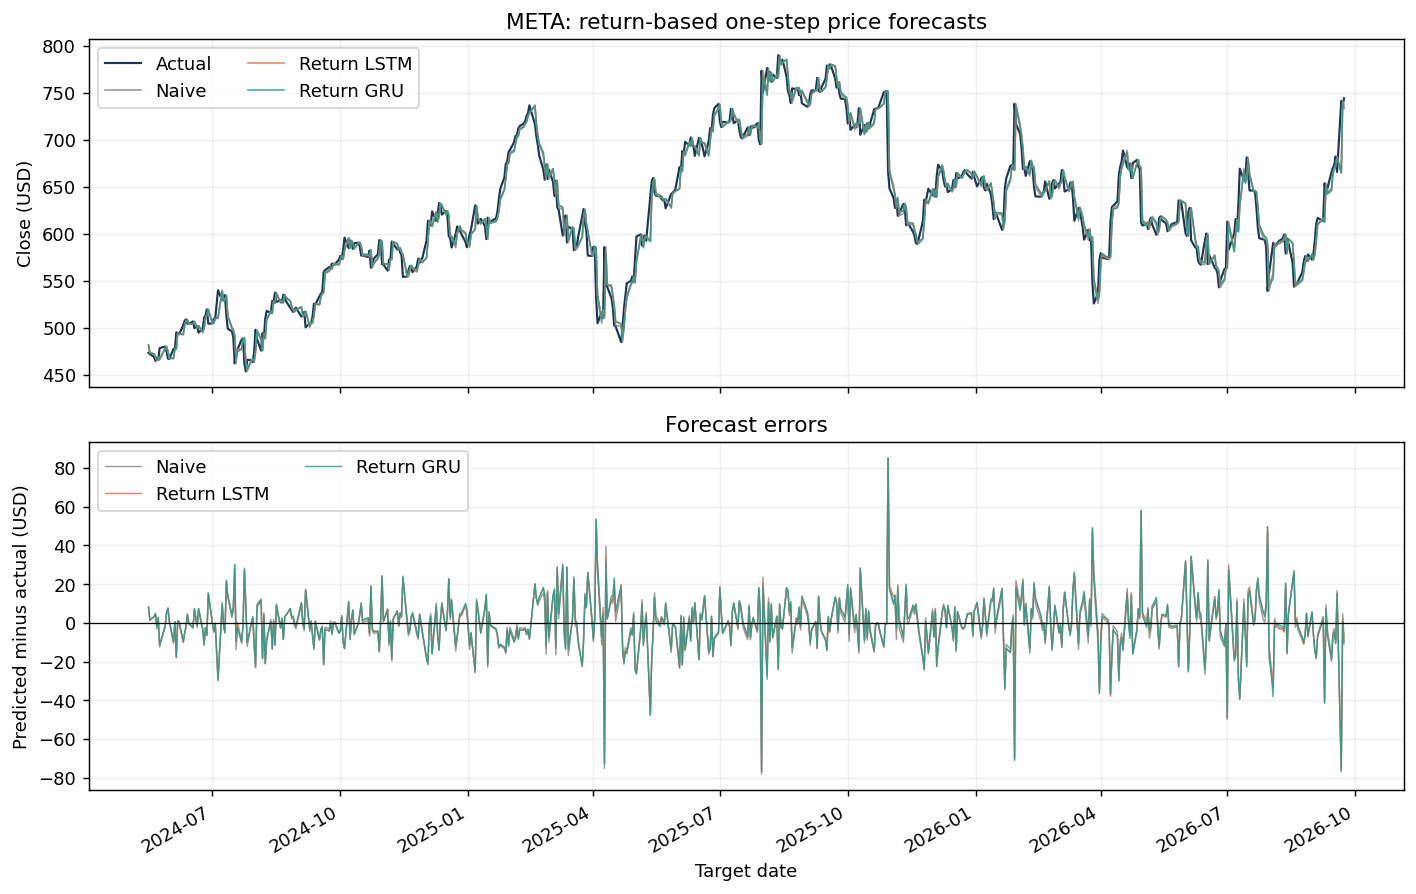

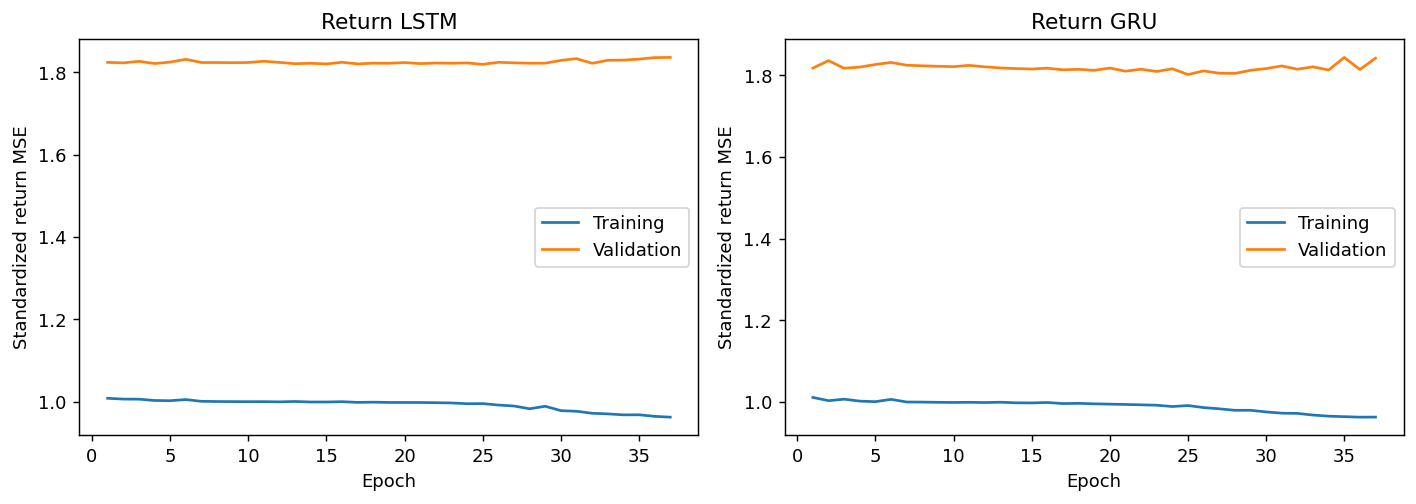

In [9]:
fig,axes=plt.subplots(2,1,figsize=(11,7),sharex=True)
axes[0].plot(test_predictions.Date,actual,color='#1d3557',label='Actual',lw=1.2)
for name,color in [('Naive','#888888'),('Return_LSTM','#e76f51'),('Return_GRU','#2a9d8f')]:
    axes[0].plot(test_predictions.Date,test_predictions[name],label=name.replace('_',' '),lw=.9,color=color,alpha=.85)
    axes[1].plot(test_predictions.Date,test_predictions[name]-actual,label=name.replace('_',' '),lw=.8,color=color,alpha=.85)
axes[0].set(title='META: return-based one-step price forecasts',ylabel='Close (USD)')
axes[1].set(title='Forecast errors',ylabel='Predicted minus actual (USD)',xlabel='Target date')
axes[1].axhline(0,color='black',lw=.7)
for ax in axes:ax.legend(ncol=2);ax.grid(alpha=.2)
fig.autofmt_xdate();fig.tight_layout();fig.savefig(RESULTS/'return_forecasts.png',dpi=160);plt.show();plt.close(fig)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,name in zip(axes,['Return_LSTM','Return_GRU']):
    h=histories[name]
    ax.plot(h.epoch,h.train_mse_scaled,label='Training')
    ax.plot(h.epoch,h.validation_mse_scaled,label='Validation')
    ax.set(title=name.replace('_',' '),xlabel='Epoch',ylabel='Standardized return MSE')
    ax.legend()
fig.tight_layout();fig.savefig(RESULTS/'return_training.png',dpi=160);plt.show();plt.close(fig)
print('Analysis complete. Test was not used for return checkpoint selection.')
